# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import os

import numpy as np
import pandas as pd

pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
tracks = pd.read_parquet("tracks.parquet")
catalog_names = pd.read_parquet("catalog_names.parquet")
interactions = pd.read_parquet("interactions.parquet")

print("tracks:", tracks.shape)
print("catalog_names:", catalog_names.shape)
print("interactions:", interactions.shape)

tracks: (1000000, 4)
catalog_names: (1812471, 3)
interactions: (222629898, 4)


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [3]:
display(tracks.head())
display(catalog_names.head())
display(interactions.head())

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


In [4]:
print("tracks info")
display(tracks.info())

print("catalog_names info")
display(catalog_names.info())

print("interactions info")
display(interactions.info())

tracks info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


None

catalog_names info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


None

interactions info
<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


None

In [5]:
print("tracks columns:", tracks.columns.tolist())
print("catalog_names columns:", catalog_names.columns.tolist())
print("interactions columns:", interactions.columns.tolist())

tracks columns: ['track_id', 'albums', 'artists', 'genres']
catalog_names columns: ['id', 'type', 'name']
interactions columns: ['user_id', 'track_id', 'track_seq', 'started_at']


In [6]:
# Проверка пропусков

print("tracks missing values:")
display(tracks.isna().sum())

print("catalog_names missing values:")
display(catalog_names.isna().sum())

print("interactions missing values:")
display(interactions.isna().sum())

tracks missing values:


track_id    0
albums      0
artists     0
genres      0
dtype: int64

catalog_names missing values:


id      0
type    0
name    0
dtype: int64

interactions missing values:


user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64

In [7]:
# Проверка типов идентификаторов

print("tracks dtypes:")
display(tracks.dtypes)

print("catalog_names dtypes:")
display(catalog_names.dtypes)

print("interactions dtypes:")
display(interactions.dtypes)

tracks dtypes:


track_id     int64
albums      object
artists     object
genres      object
dtype: object

catalog_names dtypes:


id       int64
type    object
name    object
dtype: object

interactions dtypes:


user_id                int32
track_id               int32
track_seq              int16
started_at    datetime64[ns]
dtype: object

In [8]:
# Проверка дублей

print("tracks duplicated track_id:", tracks["track_id"].duplicated().sum())
print("catalog_names duplicated id/type:", catalog_names[["id", "type"]].duplicated().sum())
print("interactions duplicated rows:", interactions.duplicated().sum())

tracks duplicated track_id: 0
catalog_names duplicated id/type: 0
interactions duplicated rows: 0


In [9]:
# Проверка неизвестных треков в interactions

known_track_ids = set(tracks["track_id"].unique())
interaction_track_ids = set(interactions["track_id"].unique())

unknown_interaction_track_ids = interaction_track_ids - known_track_ids

print("unique tracks in tracks:", len(known_track_ids))
print("unique tracks in interactions:", len(interaction_track_ids))
print("unknown track_id in interactions:", len(unknown_interaction_track_ids))

unique tracks in tracks: 1000000
unique tracks in interactions: 1000000
unknown track_id in interactions: 0


In [10]:
# Проверка неизвестных альбомов, исполнителей и жанров

def get_known_ids(catalog_names, type_name):
    return set(
        catalog_names
        .query("type == @type_name")["id"]
        .dropna()
        .unique()
    )


def get_used_ids(df, column):
    return set(
        df[column]
        .explode()
        .dropna()
        .unique()
    )


known_album_ids = get_known_ids(catalog_names, "album")
known_artist_ids = get_known_ids(catalog_names, "artist")
known_genre_ids = get_known_ids(catalog_names, "genre")

used_album_ids = get_used_ids(tracks, "albums")
used_artist_ids = get_used_ids(tracks, "artists")
used_genre_ids = get_used_ids(tracks, "genres")

unknown_album_ids = used_album_ids - known_album_ids
unknown_artist_ids = used_artist_ids - known_artist_ids
unknown_genre_ids = used_genre_ids - known_genre_ids

print("known album ids:", len(known_album_ids))
print("used album ids:", len(used_album_ids))
print("unknown album ids:", len(unknown_album_ids))

print("known artist ids:", len(known_artist_ids))
print("used artist ids:", len(used_artist_ids))
print("unknown artist ids:", len(unknown_artist_ids))

print("known genre ids:", len(known_genre_ids))
print("used genre ids:", len(used_genre_ids))
print("unknown genre ids:", len(unknown_genre_ids))

known album ids: 658724
used album ids: 658724
unknown album ids: 0
known artist ids: 153581
used artist ids: 153581
unknown artist ids: 0
known genre ids: 166
used genre ids: 173
unknown genre ids: 30


In [22]:
unknown_genre_ids_list = sorted(list(unknown_genre_ids))

print("unknown genre ids:", unknown_genre_ids_list[:30])

unknown genre ids: [124, 126, 130, 131, 132, 133, 134, 135, 146, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169]


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

### Выводы по этапу 1

На первом этапе были загружены три исходные таблицы:

* `tracks.parquet` — данные о музыкальных треках;
* `catalog_names.parquet` — справочник названий треков, альбомов, исполнителей и жанров;
* `interactions.parquet` — события прослушивания треков пользователями.

Размеры данных:

* `tracks`: 1 000 000 строк и 4 колонки;
* `catalog_names`: 1 812 471 строка и 3 колонки;
* `interactions`: 222 629 898 строк и 4 колонки.

В данных не обнаружены пропуски. Дубликаты по `track_id` в таблице `tracks`, по паре `id` / `type` в `catalog_names`, а также полные дубликаты строк в `interactions` не обнаружены.

Типы идентификаторов уже представлены в числовом формате. В таблице `interactions` идентификаторы хранятся как `int32`, а `track_seq` — как `int16`, что дополнительно снижает расход памяти на большой таблице событий. Поэтому дополнительное преобразование типов не выполнялось.

Была проверена ссылочная целостность между `interactions` и `tracks`: все треки, встречающиеся во взаимодействиях, присутствуют в справочнике треков. Количество неизвестных `track_id` в событиях равно 0.

Также была проведена проверка альбомов, исполнителей и жанров из таблицы `tracks` относительно справочника `catalog_names`. Для альбомов и исполнителей неизвестных идентификаторов не обнаружено. Для жанров обнаружено 30 идентификаторов, которые используются в `tracks`, но отсутствуют в справочнике `catalog_names`. Эти жанры не удалялись, так как проблема относится только к отсутствию справочного названия, а не к некорректности самих треков или событий прослушивания. При дальнейшем анализе такие жанры будут учитываться по идентификатору.


# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [11]:
user_track_counts = (
    interactions
    .groupby("user_id")
    .agg(track_count=("track_id", "count"))
    .reset_index()
)

display(user_track_counts.head())
display(user_track_counts["track_count"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

,user_id,track_count
0,0,26
1,1,36
2,2,14
3,3,33
4,4,256


count    1.373221e+06
mean     1.621224e+02
std      3.512846e+02
min      1.000000e+00
50%      5.500000e+01
75%      1.540000e+02
90%      3.890000e+02
95%      6.500000e+02
99%      1.576000e+03
max      1.663700e+04
Name: track_count, dtype: float64

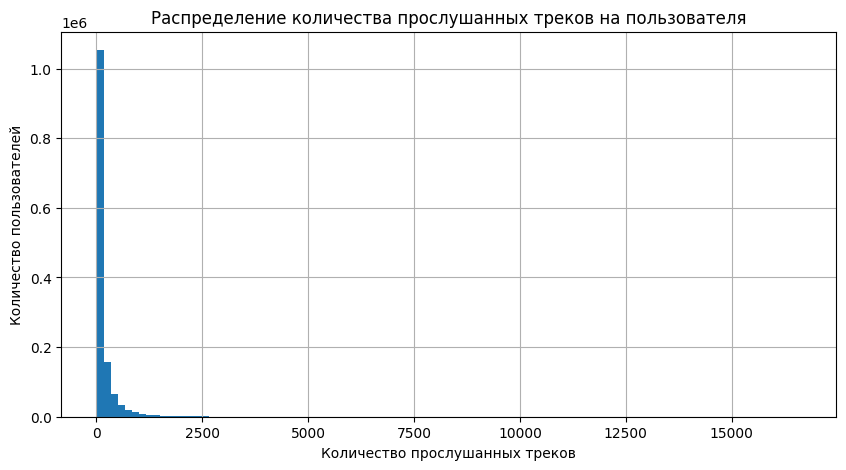

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
user_track_counts["track_count"].hist(bins=100)
plt.title("Распределение количества прослушанных треков на пользователя")
plt.xlabel("Количество прослушанных треков")
plt.ylabel("Количество пользователей")
plt.show()

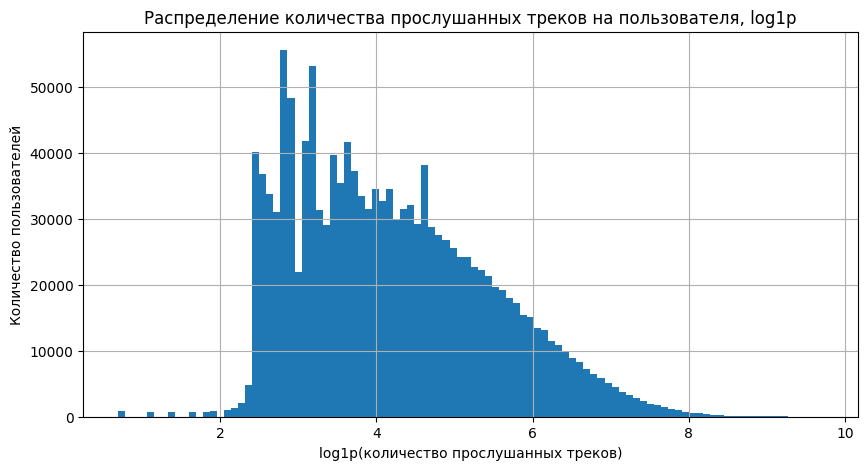

In [13]:
plt.figure(figsize=(10, 5))
np.log1p(user_track_counts["track_count"]).hist(bins=100)
plt.title("Распределение количества прослушанных треков на пользователя, log1p")
plt.xlabel("log1p(количество прослушанных треков)")
plt.ylabel("Количество пользователей")
plt.show()

Наиболее популярные треки

In [14]:
track_popularity = (
    interactions
    .groupby("track_id")
    .agg(listen_count=("user_id", "count"))
    .reset_index()
    .sort_values("listen_count", ascending=False)
)

display(track_popularity.head(10))

,track_id,listen_count
9098,53404,111062
483876,33311009,106921
26665,178529,101924
512157,35505245,99490
829320,65851540,86670
368072,24692821,86246
475289,32947997,85886
696106,51241318,85244
90461,795836,85042
647237,45499814,84748


In [15]:
# Добавим названия наиболее популярных треков

track_names = (
    catalog_names
    .query("type == 'track'")
    .rename(columns={"id": "track_id", "name": "track_name"})
    [["track_id", "track_name"]]
)

top_tracks = (
    track_popularity
    .merge(track_names, on="track_id", how="left")
)

display(top_tracks.head(20))

,track_id,listen_count,track_name
0,53404,111062,Smells Like Teen Spirit
1,33311009,106921,Believer
2,178529,101924,Numb
3,35505245,99490,I Got Love
4,65851540,86670,Юность
5,24692821,86246,Way Down We Go
6,32947997,85886,Shape of You
7,51241318,85244,In The End
8,795836,85042,Shape Of My Heart
9,45499814,84748,Life


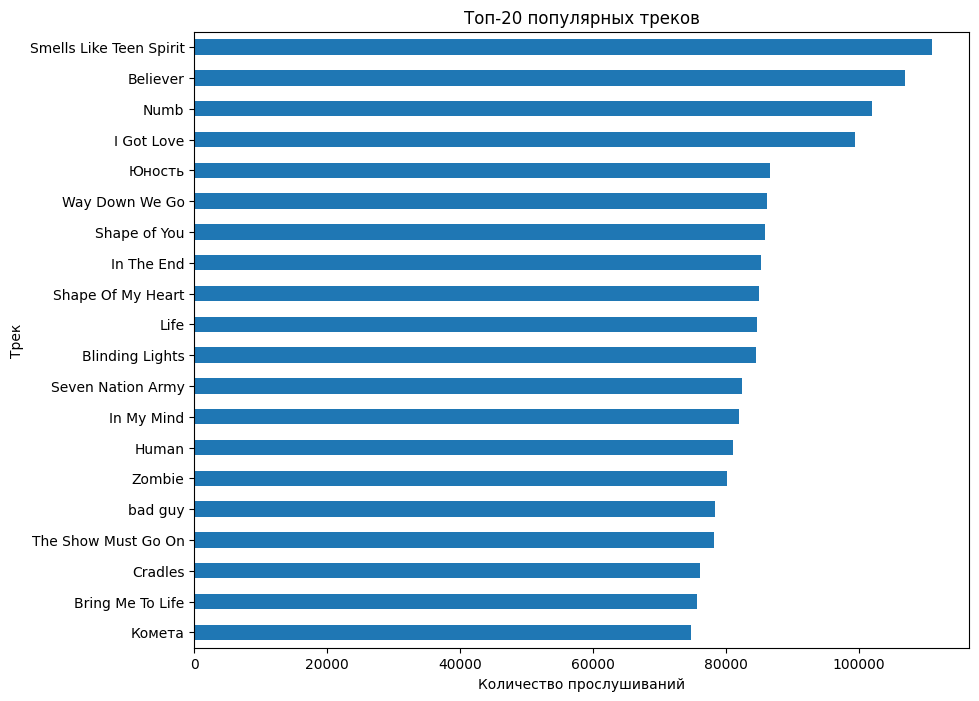

In [16]:
top_tracks.head(20).sort_values("listen_count").plot(
    kind="barh",
    x="track_name",
    y="listen_count",
    figsize=(10, 8),
    legend=False,
)

plt.title("Топ-20 популярных треков")
plt.xlabel("Количество прослушиваний")
plt.ylabel("Трек")
plt.show()

Наиболее популярные жанры

In [18]:
track_genres = tracks[["track_id", "genres"]].copy()

track_genres_popularity = (
    track_popularity
    .merge(track_genres, on="track_id", how="left")
)

track_genres_popularity = track_genres_popularity.explode("genres")
track_genres_popularity = track_genres_popularity.dropna(subset=["genres"])
track_genres_popularity["genres"] = track_genres_popularity["genres"].astype("int64")


genre_popularity = (
    track_genres_popularity
    .groupby("genres")
    .agg(listen_count=("listen_count", "sum"))
    .reset_index()
    .rename(columns={"genres": "genre_id"})
    .sort_values("listen_count", ascending=False)
)

# Добавим названия жанров

genre_names = (
    catalog_names
    .query("type == 'genre'")
    .rename(columns={"id": "genre_id", "name": "genre_name"})
    [["genre_id", "genre_name"]]
)

genre_popularity = (
    genre_popularity
    .merge(genre_names, on="genre_id", how="left")
)

display(genre_popularity.head(20))

,genre_id,listen_count,genre_name
0,11,55578312,pop
1,75,37799821,rap
2,102,31092013,allrock
3,20,26626241,ruspop
4,3,25303695,rusrap
5,68,20120981,electronics
6,16,16291557,dance
7,2,13166147,rusrock
8,14,12772644,rock
9,47,12437375,metal


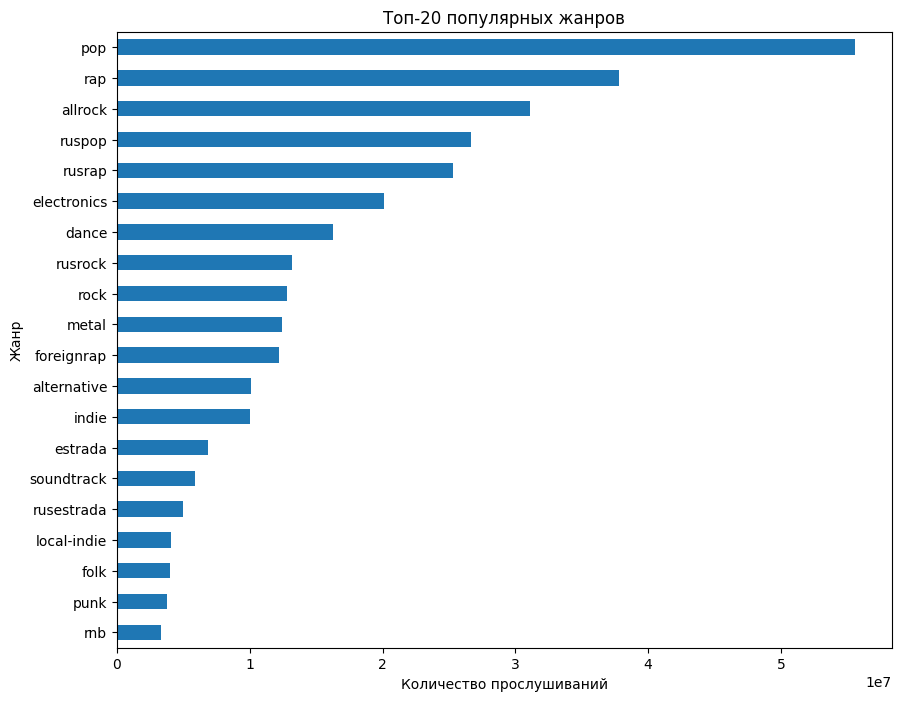

In [19]:
genre_popularity.head(20).sort_values("listen_count").plot(
    kind="barh",
    x="genre_name",
    y="listen_count",
    figsize=(10, 8),
    legend=False,
)

plt.title("Топ-20 популярных жанров")
plt.xlabel("Количество прослушиваний")
plt.ylabel("Жанр")
plt.show()

Треки, которые никто не прослушал

In [20]:
listened_track_ids = set(interactions["track_id"].unique())
all_track_ids = set(tracks["track_id"].unique())

not_listened_track_ids = all_track_ids - listened_track_ids

print("tracks total:", len(all_track_ids))
print("listened tracks:", len(listened_track_ids))
print("not listened tracks:", len(not_listened_track_ids))

tracks total: 1000000
listened tracks: 1000000
not listened tracks: 0


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [21]:
items = tracks.copy()
events = interactions.copy()

print("items:", items.shape)
print("events:", events.shape)

items: (1000000, 4)
events: (222629898, 4)


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [23]:
items = tracks.copy()
events = interactions.copy()

items.to_parquet("items.parquet", index=False)
events.to_parquet("events.parquet", index=False)

print("items.parquet saved")
print("events.parquet saved")

items.parquet saved
events.parquet saved


In [24]:
print("items.parquet:", round(os.path.getsize("items.parquet") / 1024**2, 2), "MB")
print("events.parquet:", round(os.path.getsize("events.parquet") / 1024**2, 2), "MB")

items.parquet: 18.06 MB
events.parquet: 1001.07 MB


### Выводы по этапу 2

На этапе EDA было проанализировано распределение количества прослушанных треков по пользователям, популярность треков и жанров, а также наличие треков без прослушиваний.

В датасете 1 373 221 пользователь. Распределение количества прослушанных треков на пользователя имеет длинный хвост: медианное значение равно 55 прослушиваниям, среднее — около 162, а максимальное значение достигает 16 637. Это означает, что большинство пользователей имеют относительно небольшую историю взаимодействий, но есть небольшая группа очень активных пользователей.

Самым популярным треком оказался `Smells Like Teen Spirit` с 111 062 прослушиваниями. В топ популярных треков входят как зарубежные, так и русскоязычные композиции.

Самым популярным жанром оказался `pop` — 55 578 312 прослушиваний. Далее идут `rap`, `allrock`, `ruspop`, `rusrap`, `electronics` и другие массовые жанры. При подсчёте популярности жанров прослушивание трека учитывалось во всех жанрах, к которым относится этот трек.

Отдельно была проведена проверка треков без прослушиваний. Все 1 000 000 треков из таблицы `tracks` встречаются в таблице `interactions`, поэтому треков без прослушиваний не обнаружено.

После анализа данные были сохранены локально в файлы `items.parquet` и `events.parquet`, а затем загружены в S3-бакет по пути `recsys/data/`.

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.